In [1]:
import pandas as pd
import numpy as np
#import torch
import sys
import os

import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('../'))
import Function.path as path


In [2]:
file_path = '/Volumes/bunson/Higley_Lab/Nicole/Data/audioVisual/cohort1/NA_0818_Mouse21_s01/21_20260818_0001_superanimal_topviewmouse_snapshot-hrnet_w32-004_snapshot-fasterrcnn_resnet50_fpn_v2-004.h5'

In [3]:
df = pd.read_hdf(file_path)
df.xs('nose', level="bodyparts", axis=1).droplevel(['scorer','individuals'], axis=1).loc[:, ["x", "y", "likelihood"]]

coords,x,y,likelihood
0,418.085938,320.578125,0.939699
1,418.226562,329.960938,0.903107
2,415.804688,333.242188,0.942919
3,416.726562,342.429688,0.940527
4,419.109375,349.828125,0.919691
...,...,...,...
24027,499.726562,384.945312,1.000000
24028,502.070312,388.992188,0.887961
24029,502.906250,389.695312,0.824557
24030,511.031250,389.343750,0.867772


In [13]:
df.columns.get_level_values("bodyparts").unique()

Index(['nose', 'left_ear', 'right_ear', 'left_ear_tip', 'right_ear_tip',
       'left_eye', 'right_eye', 'neck', 'mid_back', 'mouse_center',
       'mid_backend', 'mid_backend2', 'mid_backend3', 'tail_base', 'tail1',
       'tail2', 'tail3', 'tail4', 'tail5', 'left_shoulder', 'left_midside',
       'left_hip', 'right_shoulder', 'right_midside', 'right_hip', 'tail_end',
       'head_midpoint'],
      dtype='object', name='bodyparts')

In [ ]:
'nose', 'left_ear_tip', 'right_ear_tip','tail_base','neck'

In [4]:
df = pd.read_hdf(file_path)
bodypart_data = {
    bodypart: (
        df.xs(bodypart, level="bodyparts", axis=1)
          .droplevel(['scorer','individuals'], axis=1)
          .loc[:, ["x", "y", "likelihood"]]
          .copy()
    )
    for bodypart in df.columns.get_level_values("bodyparts").unique()
}

print(bodypart_data.keys())

dict_keys(['nose', 'left_ear', 'right_ear', 'left_ear_tip', 'right_ear_tip', 'left_eye', 'right_eye', 'neck', 'mid_back', 'mouse_center', 'mid_backend', 'mid_backend2', 'mid_backend3', 'tail_base', 'tail1', 'tail2', 'tail3', 'tail4', 'tail5', 'left_shoulder', 'left_midside', 'left_hip', 'right_shoulder', 'right_midside', 'right_hip', 'tail_end', 'head_midpoint'])


In [2]:
file_path = f'{path.data_path}/ribo8s002_20260804_0001DLC_resnet50_stickerNoseScopeAug4shuffle1_100000.h5'
df = pd.read_hdf(file_path)
print(df.shape)

(72771, 21)


In [3]:
bodypart_data = {
    bodypart: (
        df.xs(bodypart, level="bodyparts", axis=1)
          .droplevel("scorer", axis=1)
          .loc[:, ["x", "y", "likelihood"]]
          .copy()
    )
    for bodypart in df.columns.get_level_values("bodyparts").unique()
}

print(bodypart_data.keys())

dict_keys(['nose', 'leftEar', 'rightEar', 'scope', 'neck', 'back', 'tailBase'])


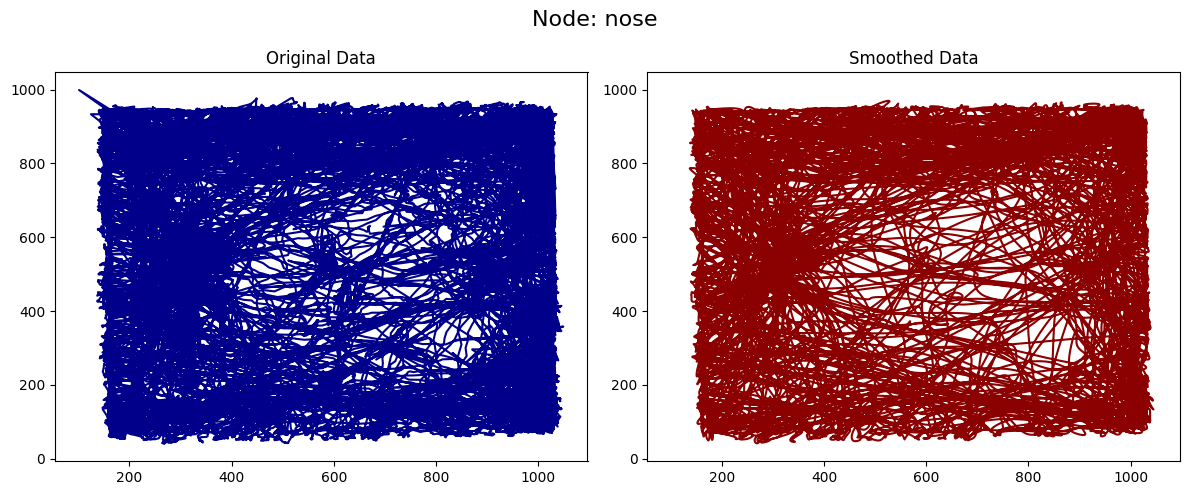

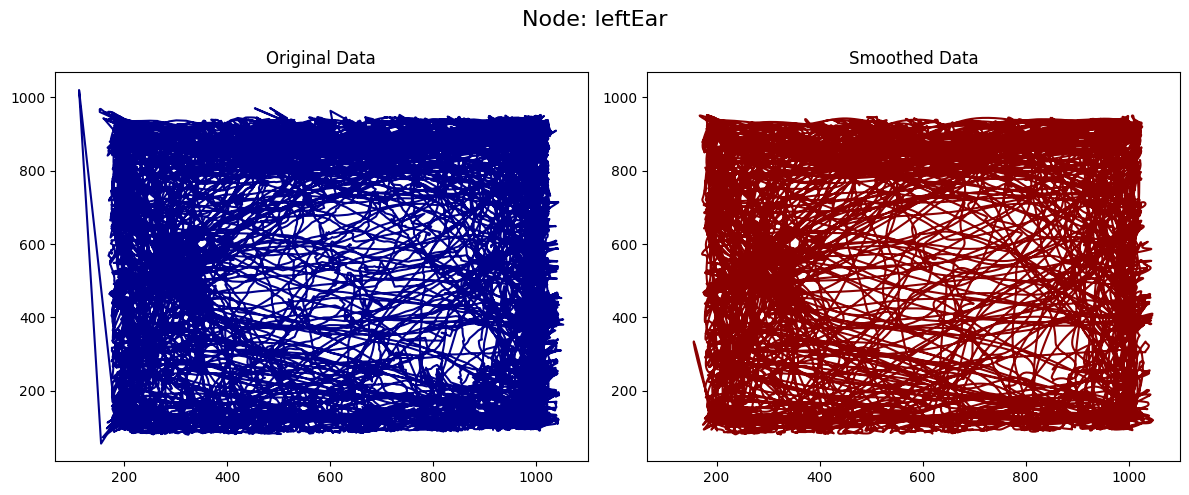

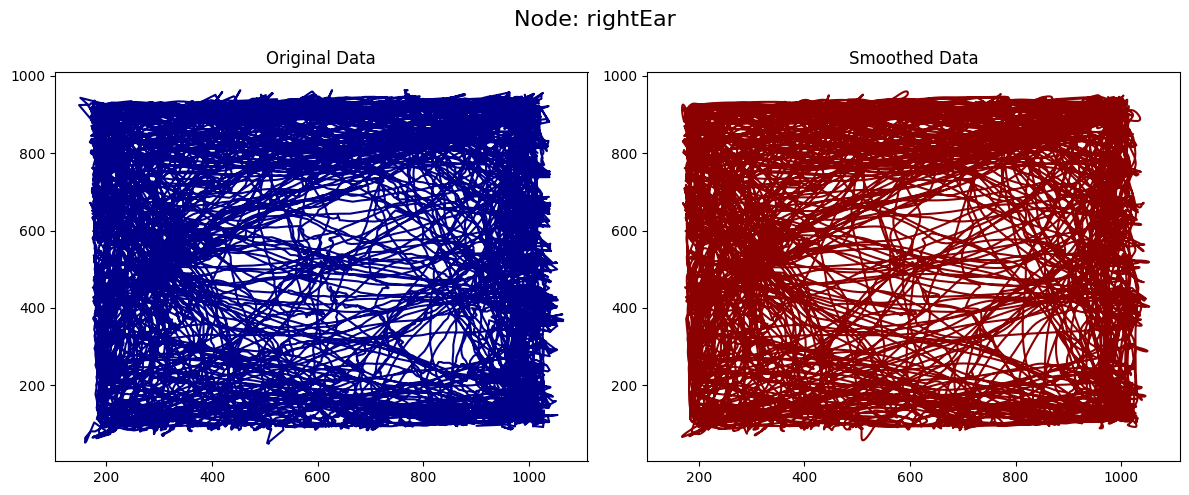

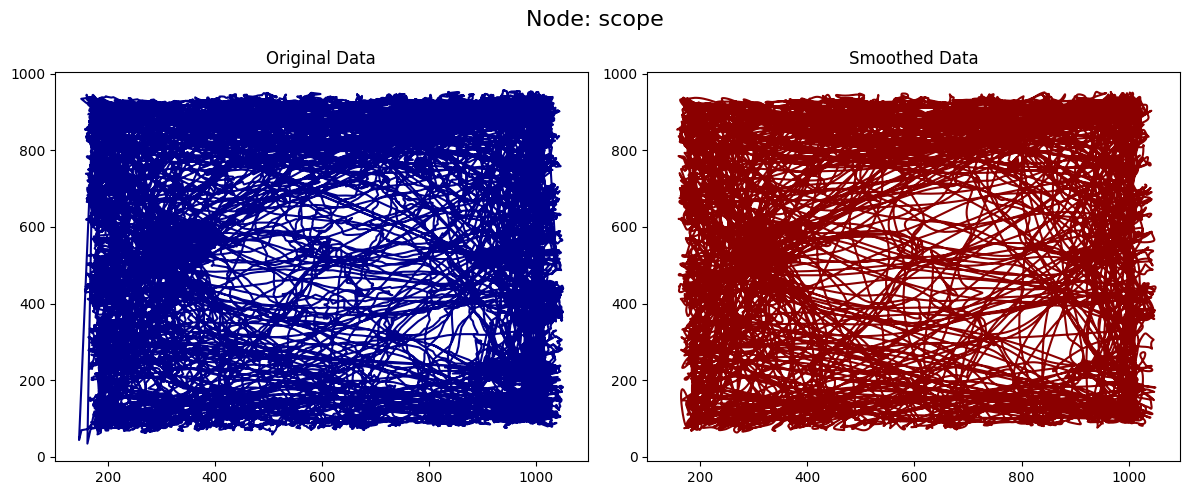

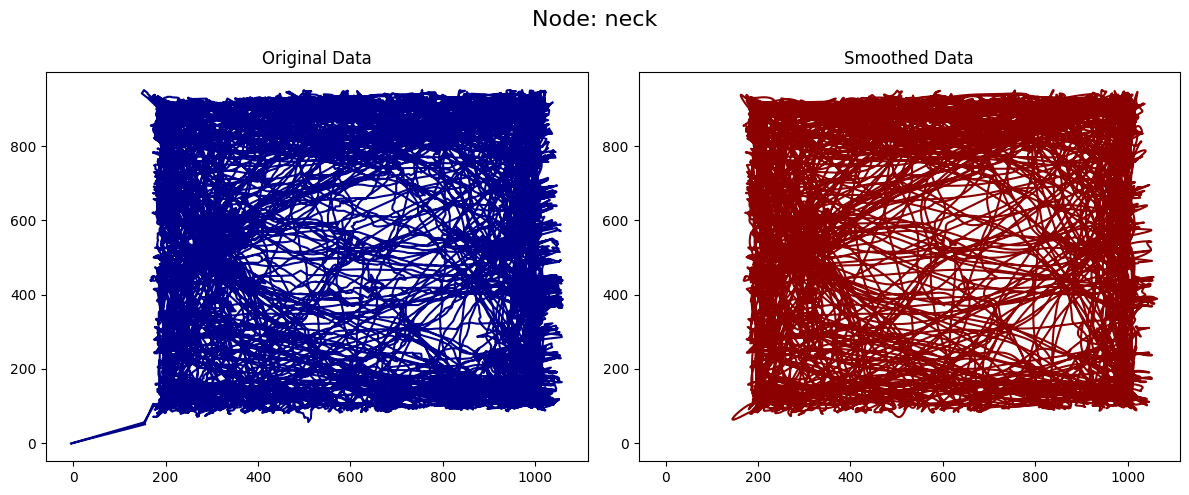

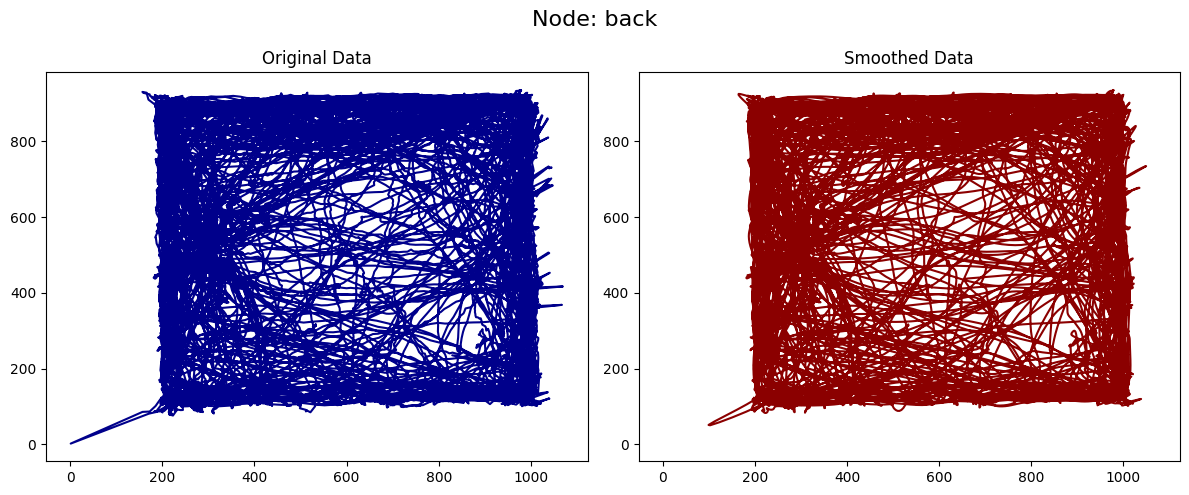

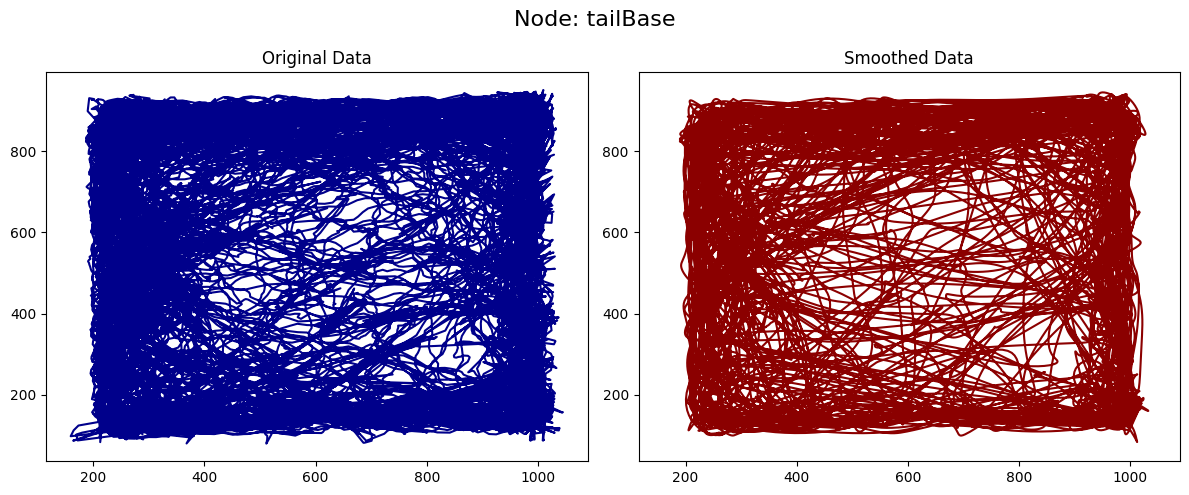

In [ ]:
for node_name in bodypart_data.keys():
    x, y = bodypart_data[node_name]['x'], bodypart_data[node_name]['y']
    
    data = np.load(f"{path.data_path}/smoothRes/{node_name}.npz")
    smoothed_x, smoothed_y = data['xnN'][0][0], data['xnN'][3][0]

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    axs[0].plot(x, y, color = 'darkblue')
    axs[0].set_title('Original Data')
    xlim = axs[0].get_xlim()
    ylim = axs[0].get_ylim()
    axs[1].plot(smoothed_x, smoothed_y, color = 'darkred')
    axs[1].set_title('Smoothed Data')
    axs[1].set_xlim(xlim)
    axs[1].set_ylim(ylim)
    fig.suptitle(f'Node: {node_name}', fontsize = 16)
    plt.tight_layout()
    plt.show()


In [5]:
from pathlib import Path

import cv2
import numpy as np


# Exact body-part names used in bodypart_data and the .npz filenames
bodyparts = [
    "nose",
    "leftEar",
    "rightEar",
    "scope",
    "neck",
    "back",
    "tailBase",
]

# Lines requested
connections = [
    ("nose", "scope"),
    ("scope", "leftEar"),
    ("scope", "rightEar"),
    ("scope", "neck"),
    ("neck", "back"),
    ("back", "tailBase"),
]


# ------------------------------------------------------------
# 1. Load all smoothed coordinates
# ------------------------------------------------------------
smoothed = {}

for name in bodyparts:
    npz_path = Path(path.data_path) / "smoothRes" / f"{name}.npz"

    with np.load(npz_path, allow_pickle=True) as data:
        smoothed[name] = {
            "x": np.asarray(data["xnN"][0][0]).squeeze(),
            "y": np.asarray(data["xnN"][3][0]).squeeze(),
        }

# Use the common number of frames in case lengths differ slightly
n_frames = min(
    min(len(coords["x"]), len(coords["y"]))
    for coords in smoothed.values()
)

print(f"Frames: {n_frames}")
print(f"Duration at 33 Hz: {n_frames / 33:.2f} seconds")


# ------------------------------------------------------------
# 2. Set the output size
# ------------------------------------------------------------
# Recommended: use the dimensions of the original video.
# Replace this with your actual video path.
original_video_path = None
# Example:
# original_video_path = "/path/to/original_video.mp4"

if original_video_path is not None:
    capture = cv2.VideoCapture(str(original_video_path))

    if not capture.isOpened():
        raise RuntimeError(f"Could not open {original_video_path}")

    frame_width = int(capture.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(capture.get(cv2.CAP_PROP_FRAME_HEIGHT))
    capture.release()

else:
    # If the original video is unavailable, infer a canvas that contains
    # every smoothed coordinate while preserving the original coordinate origin.
    all_x = np.concatenate([smoothed[name]["x"][:n_frames] for name in bodyparts])
    all_y = np.concatenate([smoothed[name]["y"][:n_frames] for name in bodyparts])

    frame_width = int(np.ceil(np.nanmax(all_x))) + 20
    frame_height = int(np.ceil(np.nanmax(all_y))) + 20

# MP4 codecs generally work best with even dimensions
frame_width += frame_width % 2
frame_height += frame_height % 2

print(f"Output dimensions: {frame_width} × {frame_height}")


# ------------------------------------------------------------
# 3. Create the video
# ------------------------------------------------------------
fps = 33.0

output_path = (
    Path(path.data_path)
    / "smoothed_skeleton_33Hz.mp4"
)

writer = cv2.VideoWriter(
    str(output_path),
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (frame_width, frame_height),
)

if not writer.isOpened():
    raise RuntimeError("Could not initialize the video writer.")

# OpenCV uses BGR colors
line_color = (40, 40, 40)          # dark gray
point_color = (30, 30, 220)        # red
scope_color = (220, 80, 30)        # blue, to distinguish scope
line_thickness = 3
point_radius = 6

for frame_index in range(n_frames):
    # White background
    frame = np.full(
        (frame_height, frame_width, 3),
        255,
        dtype=np.uint8,
    )

    current_points = {}

    # Collect valid coordinates for this frame
    for name in bodyparts:
        x = smoothed[name]["x"][frame_index]
        y = smoothed[name]["y"][frame_index]

        if np.isfinite(x) and np.isfinite(y):
            current_points[name] = (
                int(round(x)),
                int(round(y)),
            )

    # Draw connecting lines first, so points appear on top
    for start_name, end_name in connections:
        if start_name in current_points and end_name in current_points:
            cv2.line(
                frame,
                current_points[start_name],
                current_points[end_name],
                line_color,
                thickness=line_thickness,
                lineType=cv2.LINE_AA,
            )

    # Draw all body-part points
    for name, point in current_points.items():
        color = scope_color if name == "scope" else point_color

        cv2.circle(
            frame,
            point,
            point_radius,
            color,
            thickness=-1,
            lineType=cv2.LINE_AA,
        )

        # Thin black border
        cv2.circle(
            frame,
            point,
            point_radius,
            (0, 0, 0),
            thickness=1,
            lineType=cv2.LINE_AA,
        )

    writer.write(frame)

writer.release()

print(f"Saved video to:\n{output_path}")

Frames: 72771
Duration at 33 Hz: 2205.18 seconds
Output dimensions: 1084 × 990
Saved video to:
/Users/zimoli/Research/202608_FreelyMoving/Data/smoothed_skeleton_33Hz.mp4


In [6]:
from pathlib import Path

import cv2
import numpy as np


# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------
bodyparts = [
    "nose",
    "leftEar",
    "rightEar",
    "neck",
    "back",
    "tailBase",
]

connections = [
    ("nose", "neck"),
    ("leftEar", "rightEar"),
    ("neck", "back"),
    ("back", "tailBase"),
]

# OpenCV uses BGR colors.
# The same body part has the same color in both panels.
point_colors = {
    "nose":     (40, 40, 230),     # red
    "leftEar":  (0, 150, 255),     # orange
    "rightEar": (60, 190, 60),     # green
    "neck":     (230, 120, 30),    # blue
    "back":     (180, 60, 180),    # purple
    "tailBase": (180, 80, 230),    # pink
}

fps = 33.0
panel_width = 1080
panel_height = 1024
header_height = 70

point_radius = 7
line_thickness = 4
link_color = (0, 0, 0)             # black


# ------------------------------------------------------------
# 1. Load original coordinates from bodypart_data
# ------------------------------------------------------------
# Assumes:
# bodypart_data[name]["x"]
# bodypart_data[name]["y"]

original = {}

for name in bodyparts:
    original[name] = {
        "x": np.asarray(bodypart_data[name]["x"]).squeeze(),
        "y": np.asarray(bodypart_data[name]["y"]).squeeze(),
    }


# ------------------------------------------------------------
# 2. Load smoothed coordinates
# ------------------------------------------------------------
smoothed = {}

for name in bodyparts:
    npz_path = Path(path.data_path) / "smoothRes" / f"{name}.npz"

    with np.load(npz_path, allow_pickle=True) as data:
        state = np.asarray(data["xnN"])

        smoothed[name] = {
            "x": np.asarray(state[0, 0, :]).squeeze(),
            "y": np.asarray(state[3, 0, :]).squeeze(),
        }


# Use the common number of frames across original and smoothed data.
n_frames = min(
    min(
        len(original[name]["x"]),
        len(original[name]["y"]),
        len(smoothed[name]["x"]),
        len(smoothed[name]["y"]),
    )
    for name in bodyparts
)

print(f"Number of frames: {n_frames:,}")
print(f"Duration at 33 Hz: {n_frames / fps:.2f} seconds")


# ------------------------------------------------------------
# 3. Initialize side-by-side video
# ------------------------------------------------------------
output_width = panel_width * 2
output_height = panel_height + header_height

output_path = (
    Path(path.data_path)
    / "original_vs_smoothed_skeleton_33Hz.mp4"
)

writer = cv2.VideoWriter(
    str(output_path),
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (output_width, output_height),
)

if not writer.isOpened():
    raise RuntimeError("Could not initialize the video writer.")


# ------------------------------------------------------------
# Drawing functions
# ------------------------------------------------------------
def draw_centered_text(frame, text, center_x):
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 1.1
    thickness = 2

    (text_width, text_height), _ = cv2.getTextSize(
        text,
        font,
        font_scale,
        thickness,
    )

    text_x = center_x - text_width // 2
    text_y = (header_height + text_height) // 2

    cv2.putText(
        frame,
        text,
        (text_x, text_y),
        font,
        font_scale,
        (0, 0, 0),
        thickness,
        lineType=cv2.LINE_AA,
    )


def draw_skeleton(frame, coordinates, frame_index, x_offset):
    points = {}

    # Get valid coordinates.
    for name in bodyparts:
        x = coordinates[name]["x"][frame_index]
        y = coordinates[name]["y"][frame_index]

        if not (np.isfinite(x) and np.isfinite(y)):
            continue

        x = int(round(x))
        y = int(round(y))

        # Only draw points inside the original coordinate field.
        if 0 <= x < panel_width and 0 <= y < panel_height:
            points[name] = (
                x + x_offset,
                y + header_height,
            )

    # Draw all links in black.
    for start_name, end_name in connections:
        if start_name in points and end_name in points:
            cv2.line(
                frame,
                points[start_name],
                points[end_name],
                link_color,
                thickness=line_thickness,
                lineType=cv2.LINE_AA,
            )

    # Draw points over the links.
    for name in bodyparts:
        if name not in points:
            continue

        cv2.circle(
            frame,
            points[name],
            point_radius,
            point_colors[name],
            thickness=-1,
            lineType=cv2.LINE_AA,
        )

        # Thin black outline around each point.
        cv2.circle(
            frame,
            points[name],
            point_radius,
            (0, 0, 0),
            thickness=1,
            lineType=cv2.LINE_AA,
        )


# ------------------------------------------------------------
# 4. Render video
# ------------------------------------------------------------
try:
    for frame_index in range(n_frames):
        frame = np.full(
            (output_height, output_width, 3),
            255,
            dtype=np.uint8,
        )

        # Titles
        draw_centered_text(
            frame,
            "original",
            panel_width // 2,
        )

        draw_centered_text(
            frame,
            "smoothed",
            panel_width + panel_width // 2,
        )

        # Panel borders
        cv2.rectangle(
            frame,
            (0, header_height),
            (panel_width - 1, output_height - 1),
            (0, 0, 0),
            thickness=2,
        )

        cv2.rectangle(
            frame,
            (panel_width, header_height),
            (output_width - 1, output_height - 1),
            (0, 0, 0),
            thickness=2,
        )

        # Left panel: original data
        draw_skeleton(
            frame,
            original,
            frame_index,
            x_offset=0,
        )

        # Right panel: smoothed data
        draw_skeleton(
            frame,
            smoothed,
            frame_index,
            x_offset=panel_width,
        )

        writer.write(frame)

        if (frame_index + 1) % 5000 == 0:
            print(
                f"Rendered {frame_index + 1:,} / "
                f"{n_frames:,} frames"
            )

finally:
    writer.release()


print(f"Saved video to:\n{output_path}")

Number of frames: 72,771
Duration at 33 Hz: 2205.18 seconds
Rendered 5,000 / 72,771 frames
Rendered 10,000 / 72,771 frames
Rendered 15,000 / 72,771 frames
Rendered 20,000 / 72,771 frames
Rendered 25,000 / 72,771 frames
Rendered 30,000 / 72,771 frames
Rendered 35,000 / 72,771 frames
Rendered 40,000 / 72,771 frames
Rendered 45,000 / 72,771 frames
Rendered 50,000 / 72,771 frames
Rendered 55,000 / 72,771 frames
Rendered 60,000 / 72,771 frames
Rendered 65,000 / 72,771 frames
Rendered 70,000 / 72,771 frames
Saved video to:
/Users/zimoli/Research/202608_FreelyMoving/Data/original_vs_smoothed_skeleton_33Hz.mp4
